# Data Science for Cycling #1 - How To Read GPX Strava Routes With Python
- Notebook 1/6
- Make sure to have `gpxpy` installed:
<br>

```
pip install gpxpy
```

- Let's import the libraries and tweak Matplotlib's default stylings:

In [1]:
#!pip install gpxpy
#!pip install matplotlib

In [2]:
import gpxpy
import gpxpy.gpx

import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

- You can read GPX files with Python's context manager syntax:

In [3]:
with open('mapas-gpx/4021635014.gpx', 'r') as gpx_file:
    gpx = gpxpy.parse(gpx_file)

- It's a specific GPX object:

In [4]:
gpx

GPX(tracks=[GPXTrack(name='TODO', segments=[GPXTrackSegment(points=[...])])])

- Get the number of data points (number of times geolocation was taken):

In [5]:
gpx.get_track_points_no()

3357

- Get the minimum and maximum altitudes:

In [6]:
gpx.get_elevation_extremes()

MinimumMaximum(minimum=0.2, maximum=17.1)

- Get the number of meters of uphil and downhil ride
- It's a roundtrip, so the numbers should be almost identical

In [7]:
gpx.get_uphill_downhill()

UphillDownhill(uphill=101.10000000000004, downhill=103.30000000000003)

- You can dump the entire GPX file to XML
- Here are the first 1000 characters:

In [8]:
gpx.to_xml()[:1000]

'<?xml version="1.0" encoding="UTF-8"?>\n<gpx xmlns="http://www.topografix.com/GPX/1/1" xmlns:gpxtpx="http://www.garmin.com/xmlschemas/TrackPointExtension/v1" xmlns:gpxx="http://www.garmin.com/xmlschemas/GpxExtensions/v3" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.topografix.com/GPX/1/1 http://www.topografix.com/GPX/1/1/gpx.xsd http://www.garmin.com/xmlschemas/GpxExtensions/v3 http://www.garmin.com/xmlschemas/GpxExtensionsv3.xsd http://www.garmin.com/xmlschemas/TrackPointExtension/v1 http://www.garmin.com/xmlschemas/TrackPointExtensionv1.xsd" version="1.1" creator="StravaGPX Consent Strip">\n  <metadata>\n    <time>2020-07-14T22:36:55Z</time>\n  </metadata>\n  <trk>\n    <name>TODO</name>\n    <type>Run</type>\n    <trkseg>\n      <trkpt lat="-8.044875" lon="-34.939203">\n        <ele>13.4</ele>\n        <time>2020-07-14T22:36:55Z</time>\n        <extensions>\n          <gpxtpx:TrackPointExtension>\n            <gpxtpx:cad>0</gpxtpx:cad>\n     

<br>

## Basic analysis
- There's only one track available in the file
- Access it with Python's list indexing syntax:

In [9]:
gpx.tracks[0]

GPXTrack(name='TODO', segments=[GPXTrackSegment(points=[...])])

- The track has only one segment - access it the same way:

In [10]:
gpx.tracks[0].segments[0]

GPXTrackSegment(points=[...])

- The segment has 835 data points
- Here are the first 10:

In [11]:
gpx.tracks[0].segments[0].points[:10]

[GPXTrackPoint(-8.044875, -34.939203, elevation=13.4, time=datetime.datetime(2020, 7, 14, 22, 36, 55, tzinfo=SimpleTZ('Z'))),
 GPXTrackPoint(-8.044868, -34.939212, elevation=13.4, time=datetime.datetime(2020, 7, 14, 22, 36, 56, tzinfo=SimpleTZ('Z'))),
 GPXTrackPoint(-8.04486, -34.93922, elevation=13.4, time=datetime.datetime(2020, 7, 14, 22, 36, 57, tzinfo=SimpleTZ('Z'))),
 GPXTrackPoint(-8.044853, -34.939229, elevation=13.4, time=datetime.datetime(2020, 7, 14, 22, 36, 58, tzinfo=SimpleTZ('Z'))),
 GPXTrackPoint(-8.044845, -34.939238, elevation=13.4, time=datetime.datetime(2020, 7, 14, 22, 36, 59, tzinfo=SimpleTZ('Z'))),
 GPXTrackPoint(-8.044838, -34.939246, elevation=13.4, time=datetime.datetime(2020, 7, 14, 22, 37, tzinfo=SimpleTZ('Z'))),
 GPXTrackPoint(-8.04483, -34.939255, elevation=13.4, time=datetime.datetime(2020, 7, 14, 22, 37, 1, tzinfo=SimpleTZ('Z'))),
 GPXTrackPoint(-8.044823, -34.939263, elevation=13.4, time=datetime.datetime(2020, 7, 14, 22, 37, 2, tzinfo=SimpleTZ('Z'))),
 

- Let's now extract all dat apoints
- Store latitude, longitude, and elevation as a list of dicts

In [12]:
route_info = []

for track in gpx.tracks:
    for segment in track.segments:
        for point in segment.points:
            route_info.append({
                'latitude': point.latitude,
                'longitude': point.longitude,
                'elevation': point.elevation
            })

In [13]:
route_info[:3]

[{'latitude': -8.044875, 'longitude': -34.939203, 'elevation': 13.4},
 {'latitude': -8.044868, 'longitude': -34.939212, 'elevation': 13.4},
 {'latitude': -8.04486, 'longitude': -34.93922, 'elevation': 13.4}]

- Convert it to Pandas DataFrame for faster and easier analysis

In [14]:
route_df = pd.DataFrame(route_info)
route_df.head()

,latitude,longitude,elevation
0,-8.044875,-34.939203,13.4
1,-8.044868,-34.939212,13.4
2,-8.044860,-34.939220,13.4
3,-8.044853,-34.939229,13.4
4,-8.044845,-34.939238,13.4


- Save it to CSV for later use:

In [15]:
route_df.to_csv('datasets/mapas/route_df.csv', index=False)

<br>

## Basic visualization
- You can use matplotlib to visualize all data points
- It won't show the map, but you should still see how the route looks like:

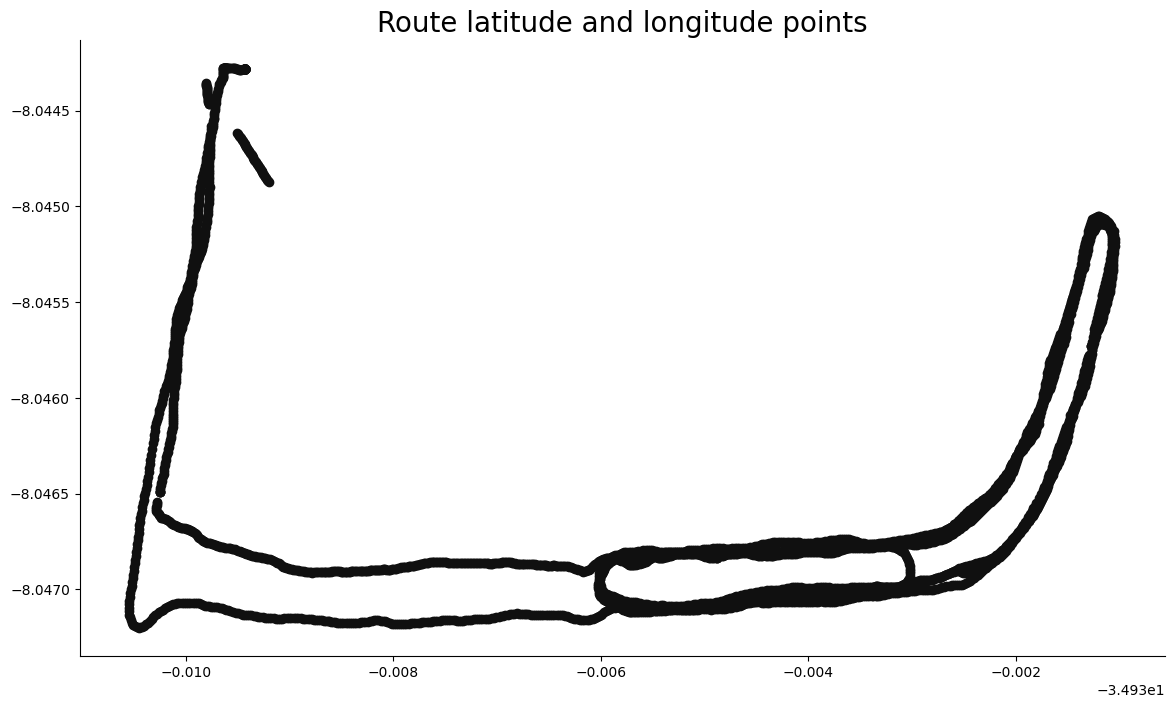

In [16]:
plt.figure(figsize=(14, 8))
plt.scatter(route_df['longitude'], route_df['latitude'], color='#101010')
plt.title('Route latitude and longitude points', size=20);

- You'll see in the following notebook how to visualize the route on a map with Folium